# NeuroScribe — End-to-End Clinical Pipeline

**Full pipeline:** Upload an EDF file → Preprocess → Detect Seizures (TCN) → Extract Features → Generate & Verify Clinical Report (LLM)

| Stage | Component | Details |
|-------|-----------|--------|
| 1 | File Input | Any CHB-MIT compatible `.edf` file |
| 2 | Preprocessing | Bandpass (0.5–40 Hz) + Notch (60 Hz) + Z-score |
| 3 | Seizure Detection | TCN (792K params, receptive field = 4s) |
| 4 | Feature Extraction | Temporal · Amplitude · Spatial · Frequency |
| 5 | Unverified Report | GPT-4o-mini — no grounding (baseline) |
| 6 | Grounded Report | GPT-4o-mini — features injected into prompt |
| 7 | Judge & Correction | GPT-5.4 — audits every claim against ground-truth |
| 8 | Final Report | Verified, claim-checked clinical EEG report |

---
## 0. Setup — API Key, Imports, Paths

In [3]:
# ── OpenAI API Key ───────────────────────────────────────────────────────────
import os
OPENAI_API_KEY = ''   # ← paste your key here (sk-...)

if OPENAI_API_KEY:
    os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY
    print('API key set.')
elif os.environ.get('OPENAI_API_KEY'):
    print('API key found in environment.')
else:
    raise EnvironmentError('No OpenAI API key found. Paste it into OPENAI_API_KEY above.')

API key set.


In [4]:
import sys, json, warnings
warnings.filterwarnings('ignore')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import yaml
from pathlib import Path
from scipy.signal import welch
from openai import OpenAI

# ── NeuroScribe imports ──────────────────────────────────────────────────────
from src.data.loader      import load_edf
from src.data.preprocessor import apply_filters, create_windows, zscore_normalize
from src.models           import TCNClassifier
from src.utils.extractor  import extract_features
from src.llm.report_generator import generate_unverified_report, generate_grounded_report
from src.llm.claim_verifier   import extract_claims, verify_claim, llm_judge_and_correct

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 110

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CKPT_PATH   = Path('checkpoints/TCN_best.pt')
RESULTS_DIR = Path('results/pipeline')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])

with open('config.yaml') as f:
    cfg = yaml.safe_load(f)

TARGET_CHANNELS = cfg['data']['channels']
FS              = cfg['data']['sample_rate']          # 256 Hz
WINDOW_SEC      = cfg['data']['window_size']          # 4 s
WINDOW_SIZE     = int(WINDOW_SEC * FS)                # 1024 samples
STEP_SIZE       = WINDOW_SIZE // 2                    # 50% overlap
THRESHOLD       = 0.5                                 # detection threshold

print(f'Device  : {DEVICE}')
print(f'Checkpoint: {CKPT_PATH}')
print(f'Results : {RESULTS_DIR}')

Device  : cuda
Checkpoint: checkpoints/TCN_best.pt
Results : results/pipeline


---
## 1. File Selection
Set `EDF_PATH` to the `.edf` file you want to analyse.  
The file must have the 23 CHB-MIT bipolar channels (or a compatible subset).

In [5]:
# ── Set the path to your EDF file here ──────────────────────────────────────
EDF_PATH    = 'data/chb-mit/chb19/chb19_10.edf'   
PATIENT_ID  = 'chb19'                               

# ── Load raw EDF ─────────────────────────────────────────────────────────────
print(f'Loading: {EDF_PATH}')
raw_data, fs_actual, ch_names = load_edf(
    EDF_PATH,
    target_channels=TARGET_CHANNELS,
    target_sfreq=FS,
)

n_ch, n_samples = raw_data.shape
duration_sec    = n_samples / FS

print(f'  Channels    : {n_ch}')
print(f'  Samples     : {n_samples:,}  ({duration_sec:.1f} s = {duration_sec/60:.1f} min)')
print(f'  Sample rate : {fs_actual} Hz')
print(f'  Amplitude   : min={raw_data.min():.1f} µV  max={raw_data.max():.1f} µV')
print(f'\nChannels: {ch_names}')

Loading: data/chb-mit/chb19/chb19_10.edf
  Channels    : 23
  Samples     : 921,600  (3600.0 s = 60.0 min)
  Sample rate : 256 Hz
  Amplitude   : min=-1015.3 µV  max=848.4 µV

Channels: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


---
## 2. Preprocessing
**Pipeline:** Bandpass filter (0.5–40 Hz) → Notch filter (60 Hz) → Z-score normalization per window

- Bandpass removes DC drift and high-frequency muscle artefact
- Notch removes US powerline interference at 60 Hz
- Z-score per window makes the model robust to inter-patient amplitude differences

Applying filters...
  Done — shape: (23, 921600)


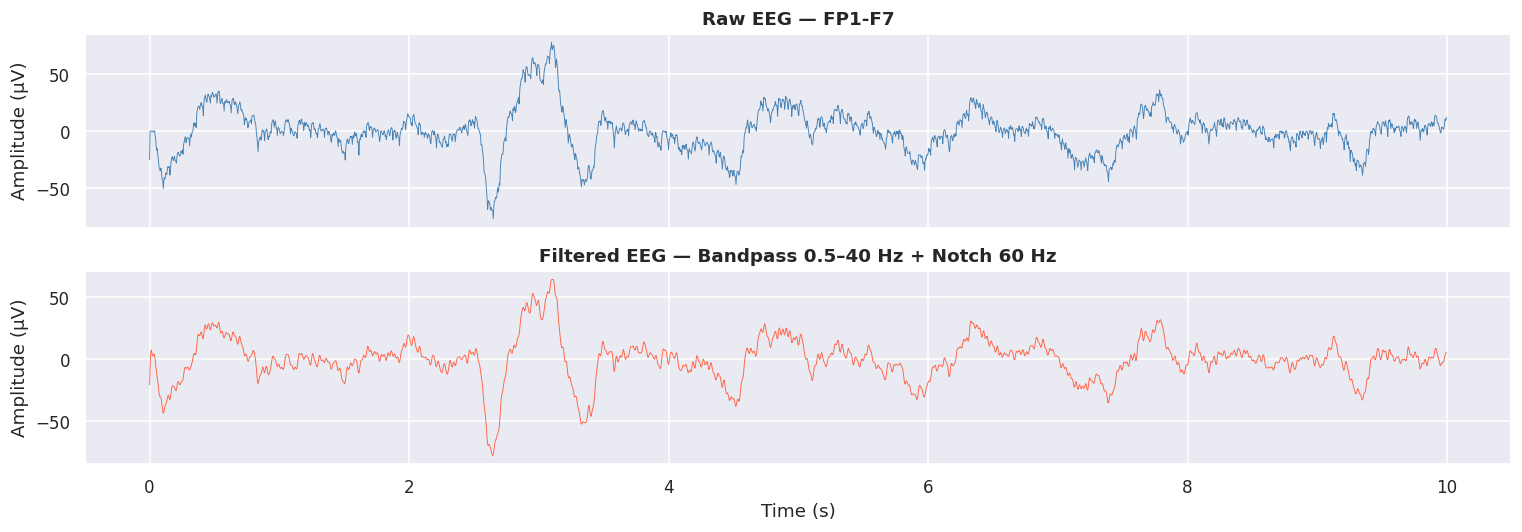

Saved → results/pipeline/preprocessing_comparison.png


In [6]:
# ── Apply bandpass + notch filters ───────────────────────────────────────────
print('Applying filters...')
filtered_data = apply_filters(
    raw_data, FS,
    bandpass_low=cfg['preprocessing']['bandpass_low'],
    bandpass_high=cfg['preprocessing']['bandpass_high'],
    notch_freq=cfg['preprocessing']['notch_freq'],
)
print(f'  Done — shape: {filtered_data.shape}')

# ── Visualise raw vs filtered for first 10s ───────────────────────────────────
plot_sec  = 10
plot_samp = int(plot_sec * FS)
t_plot    = np.arange(plot_samp) / FS
ch_idx    = 0   # FP1-F7

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(t_plot, raw_data[ch_idx, :plot_samp], color='steelblue', lw=0.6)
axes[0].set_title(f'Raw EEG — {ch_names[ch_idx]}', fontweight='bold')
axes[0].set_ylabel('Amplitude (µV)')

axes[1].plot(t_plot, filtered_data[ch_idx, :plot_samp], color='tomato', lw=0.6)
axes[1].set_title(f'Filtered EEG — Bandpass 0.5–40 Hz + Notch 60 Hz', fontweight='bold')
axes[1].set_ylabel('Amplitude (µV)')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR}/preprocessing_comparison.png')

In [7]:
# ── Segment into 4s windows with 50% overlap ─────────────────────────────────
# No ground-truth labels available for arbitrary EDF → use all-zero placeholder
dummy_labels = np.zeros(n_samples, dtype=np.int8)

windows, _ = create_windows(
    filtered_data, dummy_labels,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
)
windows = zscore_normalize(windows)   # (N, 23, 1024) float32

# Window centre times (seconds)
window_times = np.array([
    (i * STEP_SIZE + WINDOW_SIZE / 2) / FS
    for i in range(len(windows))
])

print(f'Windows : {len(windows):,}  ({WINDOW_SEC}s each, 50% overlap)')
print(f'Shape   : {windows.shape}  — ready for TCN inference')

Windows : 1,799  (4s each, 50% overlap)
Shape   : (1799, 23, 1024)  — ready for TCN inference


---
## 3. Seizure Detection — TCN Inference
The trained TCN (best checkpoint) scores every 4-second window.  
Windows with sigmoid score ≥ threshold are flagged as seizure.  
Adjacent positive windows are merged into seizure intervals.

In [8]:
# ── Load TCN checkpoint ───────────────────────────────────────────────────────
if not CKPT_PATH.exists():
    raise FileNotFoundError(
        f'Checkpoint not found: {CKPT_PATH}\n'
        'Run notebook 03_tcn_training.ipynb first to train the TCN.'
    )

tcn = TCNClassifier(
    n_channels=23, proj_channels=64,
    num_filters=128, kernel_size=3,
    num_blocks=8, dropout=0.0,   # dropout=0 at inference
).to(DEVICE)

tcn.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
tcn.eval()

params = sum(p.numel() for p in tcn.parameters())
print(f'TCN loaded  — {params:,} parameters')
print(f'Receptive field: {tcn.receptive_field} samples ({tcn.receptive_field/FS:.2f}s)')

TCN loaded  — 792,385 parameters
Receptive field: 1021 samples (3.99s)


In [9]:
# ── Run inference — batch through all windows ─────────────────────────────────
BATCH = 256
all_probs = []

with torch.no_grad():
    for i in range(0, len(windows), BATCH):
        batch = torch.from_numpy(windows[i:i+BATCH]).to(DEVICE)
        logits = tcn(batch)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)

probs_arr = np.array(all_probs)
preds_arr = (probs_arr >= THRESHOLD).astype(int)

n_positive = preds_arr.sum()
print(f'Inference done — {len(probs_arr):,} windows scored')
print(f'Seizure windows (threshold={THRESHOLD}): {n_positive} ({100*n_positive/len(probs_arr):.1f}%)')

Inference done — 1,799 windows scored
Seizure windows (threshold=0.5): 8 (0.4%)


In [10]:
# ── Merge adjacent positive windows into seizure intervals ────────────────────
def merge_intervals(times, preds, window_sec=4.0, gap_sec=2.0):
    """
    Merges consecutive positive windows into seizure intervals.
    Gaps <= gap_sec between positive windows are bridged.
    Returns list of (onset_sec, offset_sec) tuples.
    """
    intervals = []
    in_seizure = False
    onset = None
    last_pos_time = None
    half = window_sec / 2

    for t, p in zip(times, preds):
        if p == 1:
            if not in_seizure:
                onset = max(0, t - half)
                in_seizure = True
            last_pos_time = t
        else:
            if in_seizure and (t - last_pos_time) > gap_sec:
                intervals.append((onset, last_pos_time + half))
                in_seizure = False
                onset = None

    if in_seizure:
        intervals.append((onset, last_pos_time + half))

    return intervals


seizure_intervals = merge_intervals(window_times, preds_arr)

print('='*50)
if seizure_intervals:
    print(f'SEIZURE DETECTED — {len(seizure_intervals)} event(s)')
    print('='*50)
    for i, (on, off) in enumerate(seizure_intervals, 1):
        print(f'  Seizure {i}: {on:.1f}s → {off:.1f}s  (duration: {off-on:.1f}s)')
else:
    print('NO SEIZURE DETECTED in this recording.')
    print('='*50)
    print('The pipeline will still generate a report marked as seizure-free.')

SEIZURE DETECTED — 3 event(s)
  Seizure 1: 186.0s → 196.0s  (duration: 10.0s)
  Seizure 2: 818.0s → 826.0s  (duration: 8.0s)
  Seizure 3: 1336.0s → 1340.0s  (duration: 4.0s)


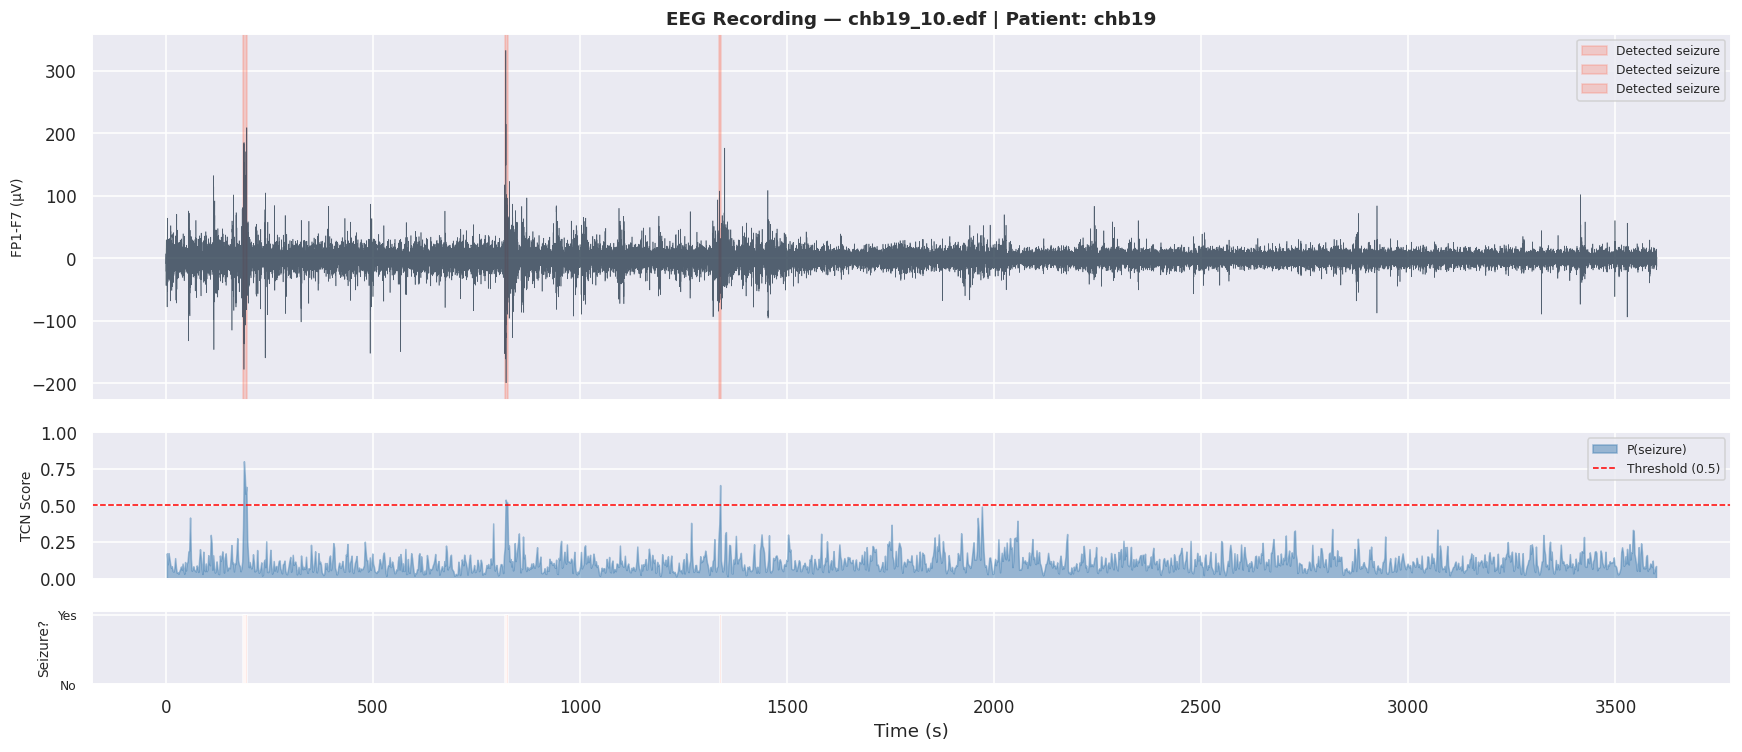

Saved → results/pipeline/detection_timeline.png


In [11]:
# ── Visualise detection timeline ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 7), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1.2, 0.6]})

# 1. EEG waveform (first channel)
t_full = np.arange(n_samples) / FS
axes[0].plot(t_full, filtered_data[0], color='#2c3e50', lw=0.4, alpha=0.8)
for on, off in seizure_intervals:
    axes[0].axvspan(on, off, color='tomato', alpha=0.25, label='Detected seizure')
axes[0].set_ylabel(f'{ch_names[0]} (µV)', fontsize=9)
axes[0].set_title(f'EEG Recording — {os.path.basename(EDF_PATH)} | Patient: {PATIENT_ID}',
                   fontweight='bold')
if seizure_intervals:
    axes[0].legend(loc='upper right', fontsize=8)

# 2. TCN probability score
axes[1].fill_between(window_times, probs_arr, alpha=0.5, color='steelblue', label='P(seizure)')
axes[1].axhline(THRESHOLD, color='red', linestyle='--', lw=1, label=f'Threshold ({THRESHOLD})')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('TCN Score', fontsize=9)
axes[1].legend(loc='upper right', fontsize=8)

# 3. Binary prediction bar
axes[2].bar(window_times, preds_arr, width=STEP_SIZE/FS,
             color=['tomato' if p else '#95a5a6' for p in preds_arr], alpha=0.85)
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(['No', 'Yes'], fontsize=8)
axes[2].set_ylabel('Seizure?', fontsize=9)
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'detection_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR}/detection_timeline.png')

---
## 4. Feature Extraction
For each detected seizure interval, extract ground-truth quantitative features:  
**Temporal** (onset, offset, duration) · **Amplitude** (RMS, peak) · **Spatial** (top channels) · **Frequency** (dominant Hz, band powers)

In [12]:
# ── Extract features for each detected seizure ────────────────────────────────
edf_filename = os.path.basename(EDF_PATH)
all_features = []

if not seizure_intervals:
    print('No seizures detected — skipping feature extraction.')
    print('Report will indicate a seizure-free recording.')
else:
    for i, (onset, offset) in enumerate(seizure_intervals, 1):
        # Clamp to valid sample range
        onset_s  = max(0.0, onset)
        offset_s = min(duration_sec, offset)
        if offset_s - onset_s < 1.0:
            print(f'  Seizure {i}: too short after clamping — skipping')
            continue
        feat = extract_features(
            filtered_data, ch_names,
            onset_sec=onset_s, offset_sec=offset_s,
            patient=PATIENT_ID, filename=edf_filename, fs=FS,
        )
        all_features.append(feat)
        print(f'  Seizure {i}: {onset_s:.1f}–{offset_s:.1f}s  '
              f'| dominant={feat["frequency"]["dominant_hz"]}Hz  '
              f'| rms={feat["amplitude"]["rms_uV"]:.1f}µV  '
              f'| top_ch={feat["spatial"]["most_active"]}')

    print(f'\nExtracted features for {len(all_features)} seizure(s).')

  Seizure 1: 186.0–196.0s  | dominant=1.0Hz  | rms=58.1µV  | top_ch=C3-P3
  Seizure 2: 818.0–826.0s  | dominant=1.0Hz  | rms=47.7µV  | top_ch=FP1-F3
  Seizure 3: 1336.0–1340.0s  | dominant=1.0Hz  | rms=23.8µV  | top_ch=F8-T8

Extracted features for 3 seizure(s).


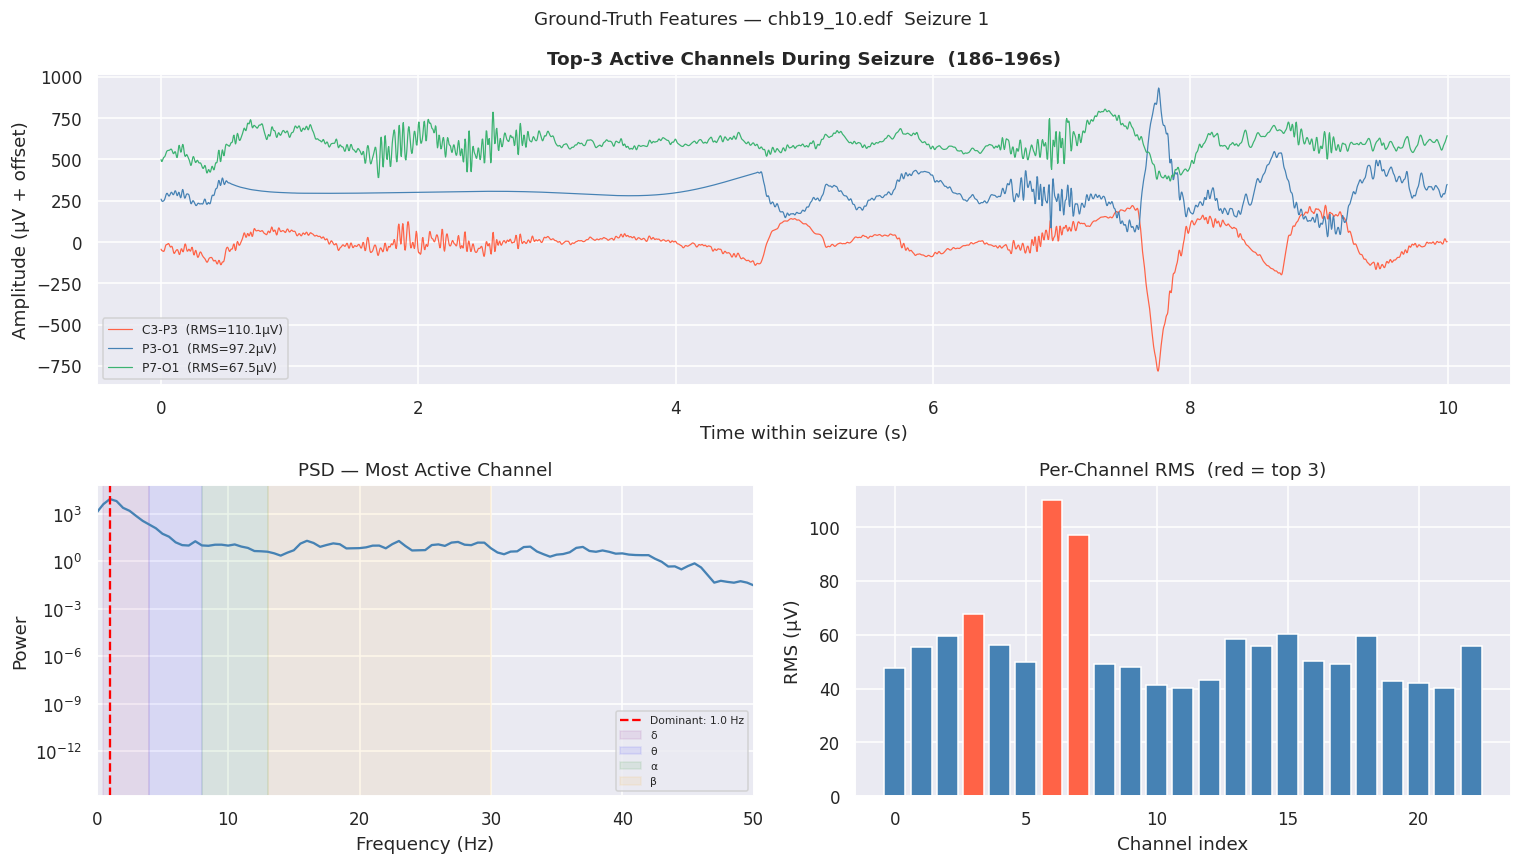

Saved → results/pipeline/features_seizure1.png

Feature dict (seizure 1):
{
  "patient": "chb19",
  "file": "chb19_10.edf",
  "temporal": {
    "onset_sec": 186.0,
    "offset_sec": 196.0,
    "duration_sec": 10.0
  },
  "amplitude": {
    "mean_uV": 40.65,
    "max_uV": 782.16,
    "rms_uV": 58.11
  },
  "spatial": {
    "top3_channels": [
      "C3-P3",
      "P3-O1",
      "P7-O1"
    ],
    "most_active": "C3-P3"
  },
  "frequency": {
    "dominant_hz": 1.0,
    "delta_power": 2115.4127,
    "theta_power": 41.6271,
    "alpha_power": 12.8883,
    "beta_power": 15.6115,
    "gamma_power": 8.1783
  }
}


In [13]:
# ── Visualise features for seizure 1 (if detected) ───────────────────────────
if not all_features:
    print('No features to visualise.')
else:
    feat   = all_features[0]
    onset  = feat['temporal']['onset_sec']
    offset = feat['temporal']['offset_sec']
    start  = int(onset  * FS)
    end    = int(offset * FS)
    seg    = filtered_data[:, start:end]

    fig = plt.figure(figsize=(14, 8))
    gs  = gridspec.GridSpec(2, 2, figure=fig)

    # 1. Top-3 channel waveforms
    ax1  = fig.add_subplot(gs[0, :])
    t_s  = np.arange(seg.shape[1]) / FS
    top3_names = feat['spatial']['top3_channels']
    top3_idx   = [ch_names.index(c) for c in top3_names if c in ch_names]
    colors = ['tomato', 'steelblue', 'mediumseagreen']
    for j, (ci, col) in enumerate(zip(top3_idx, colors)):
        ax1.plot(t_s, seg[ci] + j * 300, color=col, lw=0.8,
                 label=f'{ch_names[ci]}  (RMS={np.sqrt((seg[ci]**2).mean()):.1f}µV)')
    ax1.set_title(f'Top-3 Active Channels During Seizure  ({onset:.0f}–{offset:.0f}s)',
                   fontweight='bold')
    ax1.set_xlabel('Time within seizure (s)')
    ax1.set_ylabel('Amplitude (µV + offset)')
    ax1.legend(fontsize=8)

    # 2. PSD
    ax2 = fig.add_subplot(gs[1, 0])
    f_ax, psd = welch(seg[top3_idx[0]], fs=FS, nperseg=min(FS * 2, seg.shape[1]))
    ax2.semilogy(f_ax, psd, color='steelblue', lw=1.5)
    dom_hz = feat['frequency']['dominant_hz']
    ax2.axvline(dom_hz, color='red', linestyle='--', label=f'Dominant: {dom_hz} Hz')
    for band, (lo, hi, c) in zip(['δ','θ','α','β'],
                                   [(0.5,4,'purple'),(4,8,'blue'),(8,13,'green'),(13,30,'orange')]):
        ax2.axvspan(lo, hi, alpha=0.08, color=c, label=band)
    ax2.set_xlim(0, 50); ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('Power')
    ax2.set_title('PSD — Most Active Channel'); ax2.legend(fontsize=7)

    # 3. Per-channel RMS bar
    ax3  = fig.add_subplot(gs[1, 1])
    rms  = np.sqrt((seg ** 2).mean(axis=1))
    bar_col = ['tomato' if i in top3_idx else 'steelblue' for i in range(len(ch_names))]
    ax3.bar(range(len(ch_names)), rms, color=bar_col)
    ax3.set_xlabel('Channel index'); ax3.set_ylabel('RMS (µV)')
    ax3.set_title('Per-Channel RMS  (red = top 3)')

    plt.suptitle(f'Ground-Truth Features — {edf_filename}  Seizure 1', fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'features_seizure1.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {RESULTS_DIR}/features_seizure1.png')
    print()
    print('Feature dict (seizure 1):')
    print(json.dumps(feat, indent=2))

---
## 5. GPT-4o-mini — Unverified Report (No Grounding)
The model receives **only** the patient ID and approximate onset time — no extracted features.  
It must invent all quantitative values, which leads to **hallucination**.

In [14]:
# ── Generate unverified reports ───────────────────────────────────────────────
unverified_reports = []

if not all_features:
    print('No seizures detected — skipping report generation.')
else:
    for feat in all_features:
        print(f'Generating unverified report for [{feat["patient"]}] seizure at {feat["temporal"]["onset_sec"]:.0f}s...')
        unverified_reports.append(generate_unverified_report(client, feat))
        print('  Done.')

    print('\n' + '='*65)
    print('UNVERIFIED REPORT — Seizure 1')
    print('='*65)
    print(unverified_reports[0])

Generating unverified report for [chb19] seizure at 186s...
  Done.
Generating unverified report for [chb19] seizure at 818s...
  Done.
Generating unverified report for [chb19] seizure at 1336s...
  Done.

UNVERIFIED REPORT — Seizure 1
**EEG Clinical Report**

**Patient:** chb19  
**Recording:** chb19_10.edf  
**Date of Recording:** [Insert Date]  
**Referring Physician:** [Insert Physician Name]  
**Indication for Study:** Evaluation of seizure activity.

---

### 1. BACKGROUND ACTIVITY
The background EEG activity demonstrates a predominantly alpha rhythm with a frequency of 8-10 Hz and an amplitude of 30-50 µV, most prominent in the occipital regions. There are intermittent theta waves (4-7 Hz) with an amplitude of 20-30 µV noted in the frontal and central regions. No significant focal slowing or asymmetries were observed during the background activity. The background is reactive to eye opening and closing, with a normal response to photic stimulation.

### 2. ICTAL FINDINGS
A seizur

---
## 6. GPT-4o-mini — Grounded Report (Features Injected)
Now we provide the **full extracted feature dict** to the model.  
Every quantitative value (Hz, µV, seconds, channels) must match the ground-truth exactly.

In [15]:
# ── Generate grounded reports ─────────────────────────────────────────────────
grounded_reports = []

if not all_features:
    print('No seizures detected — skipping grounded report generation.')
else:
    for feat in all_features:
        print(f'Generating grounded report for [{feat["patient"]}]...')
        grounded_reports.append(generate_grounded_report(client, feat))
        print('  Done.')

    print('\n' + '='*65)
    print('GROUNDED REPORT — Seizure 1 (features injected)')
    print('='*65)
    print(grounded_reports[0])

Generating grounded report for [chb19]...
  Done.
Generating grounded report for [chb19]...
  Done.
Generating grounded report for [chb19]...
  Done.

GROUNDED REPORT — Seizure 1 (features injected)
**EEG Clinical Report**

**Patient:** chb19  
**Recording:** chb19_10.edf  
**Date of Recording:** [Insert Date Here]  
**Electroencephalogram (EEG) Findings:**  

---

### 1. BACKGROUND ACTIVITY
The background EEG activity was characterized predominantly by alpha rhythms occurring in the posterior regions, with variations observed in amplitude and frequency across different channels. No significant abnormalities in background activity were noted prior to the seizure event. The overall background activity was within normal limits for the patient's age and clinical history.

### 2. ICTAL FINDINGS
The seizure was identified with a clear onset at 186.0 seconds and offset at 196.0 seconds, resulting in a total duration of 10.0 seconds. During this period, a dominant frequency of 1.0 Hz was note

---
## 7. Hallucination Analysis — Unverified vs Grounded
Extract atomic claims from each report and cross-check every value against ground-truth.

In [16]:
# ── Claim extraction + verification ──────────────────────────────────────────
unverified_results = []
grounded_results   = []

if not all_features:
    print('No features available — skipping hallucination analysis.')
else:
    for feat, u_rep, g_rep in zip(all_features, unverified_reports, grounded_reports):
        for claim in extract_claims(u_rep):
            v, gt, _ = verify_claim(claim, feat)
            unverified_results.append({'Stage': 'Unverified', 'Category': claim['category'],
                                        'Claim': claim['claim_text'], 'GT': gt, 'Verdict': v})
        for claim in extract_claims(g_rep):
            v, gt, _ = verify_claim(claim, feat)
            grounded_results.append({'Stage': 'Grounded', 'Category': claim['category'],
                                      'Claim': claim['claim_text'], 'GT': gt, 'Verdict': v})

    df_u = pd.DataFrame(unverified_results)
    df_g = pd.DataFrame(grounded_results)

    def halluc_rate(df):
        v = df[df['Verdict'] != 'UNVERIFIABLE']
        n_h = (v['Verdict'] == 'HALLUCINATED').sum()
        return n_h / max(len(v), 1), n_h, len(v)

    rate_u, n_hu, n_u = halluc_rate(df_u)
    rate_g, n_hg, n_g = halluc_rate(df_g)

    print(f'Unverified : {rate_u:.1%} hallucination  ({n_hu}/{n_u} claims)')
    print(f'Grounded   : {rate_g:.1%} hallucination  ({n_hg}/{n_g} claims)')
    print()
    print('Claim breakdown (unverified):')
    print(df_u[df_u['Verdict'] != 'UNVERIFIABLE'][['Category','Claim','GT','Verdict']].to_string(index=False))

Unverified : 88.9% hallucination  (32/36 claims)
Grounded   : 37.1% hallucination  (13/35 claims)

Claim breakdown (unverified):
 Category      Claim                              GT      Verdict
frequency    8-10 Hz                          1.0 Hz HALLUCINATED
frequency     4-7 Hz                          1.0 Hz HALLUCINATED
frequency     3-4 Hz                          1.0 Hz HALLUCINATED
amplitude   30-50 µV                   58.1 µV (RMS) HALLUCINATED
amplitude   20-30 µV                   58.1 µV (RMS) HALLUCINATED
amplitude 100-150 µV                   58.1 µV (RMS) HALLUCINATED
 duration    186 sec                          10.0 s HALLUCINATED
 duration     30 sec                          10.0 s HALLUCINATED
 duration     10 sec                          10.0 s     VERIFIED
  channel         T6     ['C3-P3', 'P3-O1', 'P7-O1'] HALLUCINATED
  channel         F8     ['C3-P3', 'P3-O1', 'P7-O1'] HALLUCINATED
frequency    8-12 Hz                          1.0 Hz HALLUCINATED
frequency    

---
## 8. GPT-5.4 Judge & Corrector (LLM-as-a-Judge)
GPT-5.4 receives the **unverified report** + the **ground-truth feature dict**.  
It independently audits every claim and rewrites the report with all hallucinated values corrected.

In [17]:
# ── Run GPT-5.4 judge on unverified reports ───────────────────────────────────
judge_outputs = []

if not all_features:
    print('No seizures detected — skipping judge stage.')
else:
    for feat, report in zip(all_features, unverified_reports):
        print(f'Running GPT-5.4 judge for [{feat["patient"]}] seizure at {feat["temporal"]["onset_sec"]:.0f}s...')
        judge_outputs.append(llm_judge_and_correct(client, report, feat))
        print('  Done.')

    print('\n' + '='*65)
    print('GPT-5.4 AUDIT — Seizure 1')
    print('='*65)
    print(judge_outputs[0]['audit_section'])

Running GPT-5.4 judge for [chb19] seizure at 186s...
  Done.
Running GPT-5.4 judge for [chb19] seizure at 818s...
  Done.
Running GPT-5.4 judge for [chb19] seizure at 1336s...
  Done.

GPT-5.4 AUDIT — Seizure 1
| Report section | Quantitative / specific claim from AI report | Status | Ground-truth / audit note |
|---|---|---:|---|
| Background activity | Alpha rhythm **8–10 Hz** | **HALLUCINATED** | No ground-truth background frequency provided |
| Background activity | Background amplitude **30–50 µV** | **HALLUCINATED** | No ground-truth background amplitude provided |
| Background activity | Intermittent theta **4–7 Hz** | **HALLUCINATED** | No ground-truth background theta frequency provided |
| Background activity | Theta amplitude **20–30 µV** | **HALLUCINATED** | No ground-truth background theta amplitude provided |
| Ictal findings | Seizure onset at **approximately 186 seconds** | **VERIFIED** | Seizure onset **186.0 s** |
| Ictal findings | Focal onset in **right temporal reg

In [18]:
# ── Verify claims in corrected reports ───────────────────────────────────────
corrected_results = []

if judge_outputs:
    for feat, jout in zip(all_features, judge_outputs):
        for claim in extract_claims(jout['corrected_report']):
            v, gt, _ = verify_claim(claim, feat)
            corrected_results.append({'Stage': 'Corrected', 'Category': claim['category'],
                                       'Claim': claim['claim_text'], 'GT': gt, 'Verdict': v})

    df_c = pd.DataFrame(corrected_results)
    rate_c, n_hc, n_c = halluc_rate(df_c)

    print(f'GPT-5.4 corrected : {rate_c:.1%} hallucination  ({n_hc}/{n_c} claims)')
    print()
    print('='*65)
    print('FINAL VERIFIED REPORT — Seizure 1')
    print('='*65)
    print(judge_outputs[0]['corrected_report'])

GPT-5.4 corrected : 31.6% hallucination  (6/19 claims)

FINAL VERIFIED REPORT — Seizure 1
**EEG Clinical Report**

**Patient:** chb19  
**Recording:** chb19_10.edf  
**Date of Recording:** [Insert Date]  
**Referring Physician:** [Insert Physician Name]  
**Indication for Study:** Evaluation of seizure activity.

---

### 1. BACKGROUND ACTIVITY
Background activity is present throughout the recording. Specific quantitative background frequency and amplitude values are not verified from the provided signal-feature summary. No definitive statement regarding reactivity, photic response, focal slowing, or asymmetry can be confirmed from the available ground-truth data alone.

### 2. ICTAL FINDINGS
A seizure event was detected at **186.0 seconds** into the recording. The seizure ended at **196.0 seconds**, for a total duration of **10.0 seconds**. The ictal activity showed a **dominant frequency of 1.0 Hz**. The measured ictal **RMS amplitude was 58.1 µV**, with a **peak amplitude of 782.2 µ

---
## 9. Pipeline Summary & Visualisation

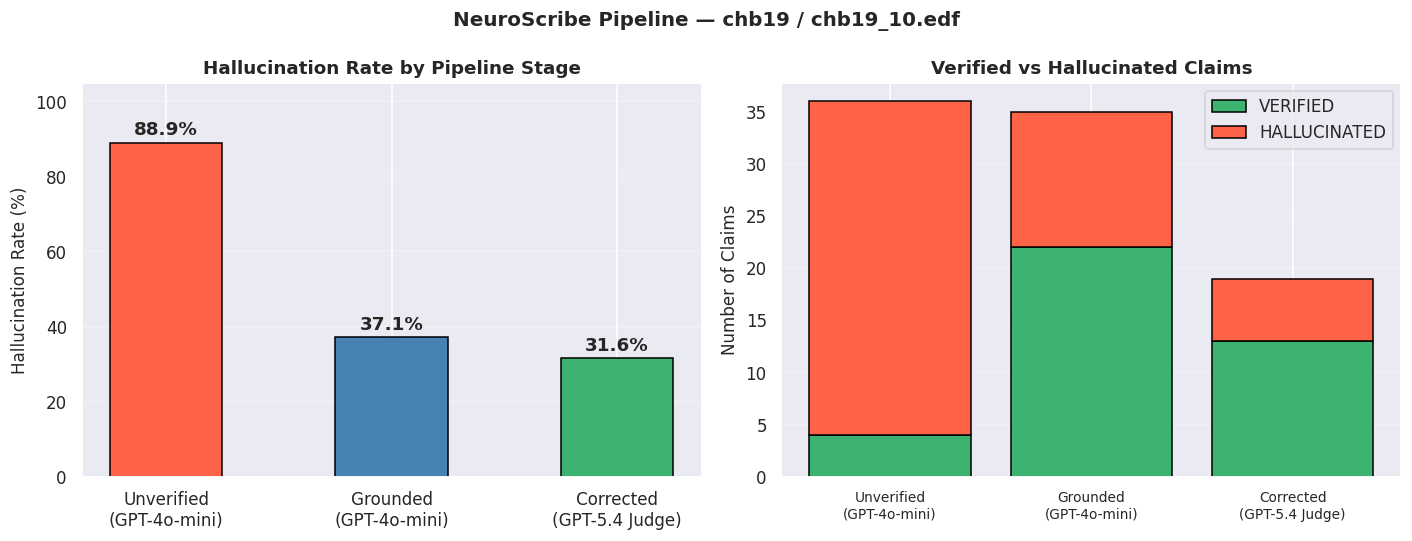

Saved → results/pipeline/pipeline_hallucination_comparison.png


In [19]:
# ── Three-stage hallucination comparison plot ────────────────────────────────
if not all_features or not judge_outputs:
    print('No data to plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    approaches = ['Unverified\n(GPT-4o-mini)', 'Grounded\n(GPT-4o-mini)', 'Corrected\n(GPT-5.4 Judge)']
    hall_rates = [rate_u * 100, rate_g * 100, rate_c * 100]
    bar_cols   = ['tomato', 'steelblue', 'mediumseagreen']

    bars = axes[0].bar(approaches, hall_rates, color=bar_cols, edgecolor='black', width=0.5)
    for bar, val in zip(bars, hall_rates):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    axes[0].set_ylim(0, 105)
    axes[0].set_ylabel('Hallucination Rate (%)', fontsize=11)
    axes[0].set_title('Hallucination Rate by Pipeline Stage', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)

    n_verif_counts = [n_u - n_hu, n_g - n_hg, n_c - n_hc]
    n_hall_counts  = [n_hu, n_hg, n_hc]
    x = range(3)
    axes[1].bar(x, n_verif_counts, label='VERIFIED',     color='mediumseagreen', edgecolor='black')
    axes[1].bar(x, n_hall_counts, bottom=n_verif_counts, label='HALLUCINATED', color='tomato', edgecolor='black')
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(approaches, fontsize=9)
    axes[1].set_ylabel('Number of Claims', fontsize=11)
    axes[1].set_title('Verified vs Hallucinated Claims', fontweight='bold')
    axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle(f'NeuroScribe Pipeline — {PATIENT_ID} / {edf_filename}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'pipeline_hallucination_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {RESULTS_DIR}/pipeline_hallucination_comparison.png')

In [20]:
# ── Save results & print final summary ───────────────────────────────────────
summary = {
    'patient':       PATIENT_ID,
    'file':          edf_filename,
    'duration_sec':  round(duration_sec, 1),
    'n_windows':     len(windows),
    'seizures_detected': len(seizure_intervals),
    'seizure_intervals': [(round(a, 1), round(b, 1)) for a, b in seizure_intervals],
}

if all_features:
    summary['features_seizure1']       = all_features[0]
    summary['hallucination_unverified'] = round(rate_u, 4)
    summary['hallucination_grounded']   = round(rate_g, 4)
    summary['hallucination_corrected']  = round(rate_c, 4)
    summary['final_report']             = judge_outputs[0]['corrected_report'] if judge_outputs else ''

    # Save claim tables
    pd.concat([df_u, df_g, df_c]).to_csv(RESULTS_DIR / 'all_claims.csv', index=False)
    print(f'Saved → {RESULTS_DIR}/all_claims.csv')

with open(RESULTS_DIR / 'pipeline_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(f'Saved → {RESULTS_DIR}/pipeline_summary.json')

print()
print('=' * 60)
print('NEUROSCRIBE PIPELINE — FINAL SUMMARY')
print('=' * 60)
print(f'  Patient          : {PATIENT_ID}')
print(f'  File             : {edf_filename}')
print(f'  Duration         : {duration_sec:.0f}s ({duration_sec/60:.1f} min)')
print(f'  Windows scored   : {len(windows):,}')
print(f'  Seizures found   : {len(seizure_intervals)}')
for i, (on, off) in enumerate(seizure_intervals, 1):
    print(f'    [{i}] {on:.1f}s → {off:.1f}s  ({off-on:.1f}s)')
if all_features:
    print(f'  Hallucination rates:')
    print(f'    Unverified (GPT-4o-mini)  : {rate_u:.1%}')
    print(f'    Grounded   (GPT-4o-mini)  : {rate_g:.1%}')
    print(f'    Corrected  (GPT-5.4 Judge): {rate_c:.1%}')
print('=' * 60)

Saved → results/pipeline/all_claims.csv
Saved → results/pipeline/pipeline_summary.json

NEUROSCRIBE PIPELINE — FINAL SUMMARY
  Patient          : chb19
  File             : chb19_10.edf
  Duration         : 3600s (60.0 min)
  Windows scored   : 1,799
  Seizures found   : 3
    [1] 186.0s → 196.0s  (10.0s)
    [2] 818.0s → 826.0s  (8.0s)
    [3] 1336.0s → 1340.0s  (4.0s)
  Hallucination rates:
    Unverified (GPT-4o-mini)  : 88.9%
    Grounded   (GPT-4o-mini)  : 37.1%
    Corrected  (GPT-5.4 Judge): 31.6%
